# Week 2 - Datasets and Pre-processing

## Machine Learning for Engineering Applications

## By the end of this seminar you should be able to:
* Apply statistical foundations — mean, median, standard deviation, correlation, and distribution analysis to real data
* Handle missing data using removal, imputation, interpolation, and model-based methods appropriate to engineering contexts
* Detect and evaluate outliers using z-score, IQR, and boxplot methods — combined with engineering judgement
* Perform feature scaling and encoding — normalization, standardization, robust scaling, and categorical variable encoding
* Implement complete preprocessing workflows in Python using pandas, numpy, scikit-learn, and proper train/test split protocols

Please note the dataset is **synthetic** and is designed for teaching rather than representing a real machine.

More instructions on how to preprocess data and handle missing data in scikit-learn can be found at: https://scikit-learn.org/stable/modules/preprocessing.html and https://scikit-learn.org/stable/modules/impute.html


## Dataset Overview: Predictive Maintenance of Rotating Machinery
In this lab, you will work with a vibration monitoring dataset collected from a simulated industrial rotating machine. The objective is to use machine learning techniques to identify the health condition of the machine based on measurements obtained from vibration sensors and operating parameters.

The dataset contains observations from four different operating conditions:

* Healthy: Normal machine operation with low vibration levels.
* Run-Up (Transient): Machine accelerating from low to rated speed. These data points represent normal but non-steady-state behaviour.
* Bearing Fault: Simulated inner-race bearing damage, resulting in increased vibration levels and impulsive behaviour.
* Rotor Imbalance: Uneven mass distribution on the rotating shaft, causing elevated vibration at the rotational frequency.

For each observation, several sensor-derived features are available:

* RPM: Rotational speed of the machine.
* Temperature: Operating temperature.
* RMS Vibration: Overall vibration energy.
* Peak Vibration: Maximum vibration amplitude.
* Kurtosis: Indicator of impulsive events often associated with bearing faults.
* Skewness: Measure of the asymmetry of the vibration signal distribution.

To make the dataset more representative of real industrial data, several common data quality issues have been intentionally included:

* Missing values
* Duplicate records
* Outliers caused by sensor spikes
* Transient run-up conditions

Before building a machine learning model, you should investigate and address these issues through an appropriate preprocessing pipeline. Typical preprocessing steps include duplicate removal, missing value treatment, outlier analysis, feature scaling, and exploratory data analysis.

The primary task is to use the sensor measurements to classify the machine condition (FaultLabel), allowing the development of a simple predictive maintenance model capable of distinguishing between healthy operation and different fault types. This exercise demonstrates the complete workflow from raw engineering data to machine learning-based condition monitoring.


#### Load the dataset and inspect the data structure

In [1]:
import pandas as pd
df = pd.read_csv('sensor_data.csv')

In [2]:
print(df.shape)

(423, 10)


In [3]:
print(df.head())

   RecordID  Time_s     RPM  Temperature_C  RMS_g  Peak_g  Kurtosis  Skewness  \
0         1       0  1796.2           46.8  0.213   0.746      2.82     -0.32   
1         2       5  1796.8           47.7  0.233   0.815      4.03      0.15   
2         3      10  1805.9           46.3  0.170   0.595      3.87      0.25   
3         4      15  1807.5           43.5  0.168   0.587      2.30     -0.14   
4         5      20  1804.6           45.9  0.236   0.825      2.52      0.17   

  OperatingState FaultLabel  
0        Healthy    Healthy  
1        Healthy    Healthy  
2        Healthy    Healthy  
3        Healthy    Healthy  
4        Healthy    Healthy  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RecordID        423 non-null    int64  
 1   Time_s          423 non-null    int64  
 2   RPM             420 non-null    float64
 3   Temperature_C   423 non-null    float64
 4   RMS_g           416 non-null    float64
 5   Peak_g          423 non-null    float64
 6   Kurtosis        423 non-null    float64
 7   Skewness        423 non-null    float64
 8   OperatingState  423 non-null    object 
 9   FaultLabel      423 non-null    object 
dtypes: float64(6), int64(2), object(2)
memory usage: 33.2+ KB


In [5]:
df.describe()

,RecordID,Time_s,RPM,Temperature_C,RMS_g,Peak_g,Kurtosis,Skewness
count,423.000000,423.000000,420.000000,423.000000,416.000000,423.000000,423.000000,423.000000
mean,210.281324,1046.406619,1726.408333,51.984161,0.626591,2.809501,5.954823,0.077234
std,121.313970,606.569852,232.715643,4.856574,0.280377,1.454988,1.757517,0.385569
min,1.000000,0.000000,611.500000,42.000000,0.149000,0.522000,0.640000,-1.040000
25%,105.500000,522.500000,1777.100000,47.800000,0.418250,1.878500,5.040000,-0.205000
50%,210.000000,1045.000000,1796.300000,51.700000,0.638000,2.864000,6.430000,0.080000
75%,314.500000,1567.500000,1811.125000,55.900000,0.859750,3.931000,7.205000,0.350000
max,420.000000,2095.000000,1864.400000,63.400000,1.238000,10.220000,9.400000,1.240000


#### Identify missing values

In [6]:
df.isnull().sum()

RecordID          0
Time_s            0
RPM               3
Temperature_C     0
RMS_g             7
Peak_g            0
Kurtosis          0
Skewness          0
OperatingState    0
FaultLabel        0
dtype: int64

In [7]:
df.isnull().sum() / len(df)

RecordID          0.000000
Time_s            0.000000
RPM               0.007092
Temperature_C     0.000000
RMS_g             0.016548
Peak_g            0.000000
Kurtosis          0.000000
Skewness          0.000000
OperatingState    0.000000
FaultLabel        0.000000
dtype: float64

#### Visualise missing data

In [ ]:
# Missing Data Heatmap

In [8]:
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

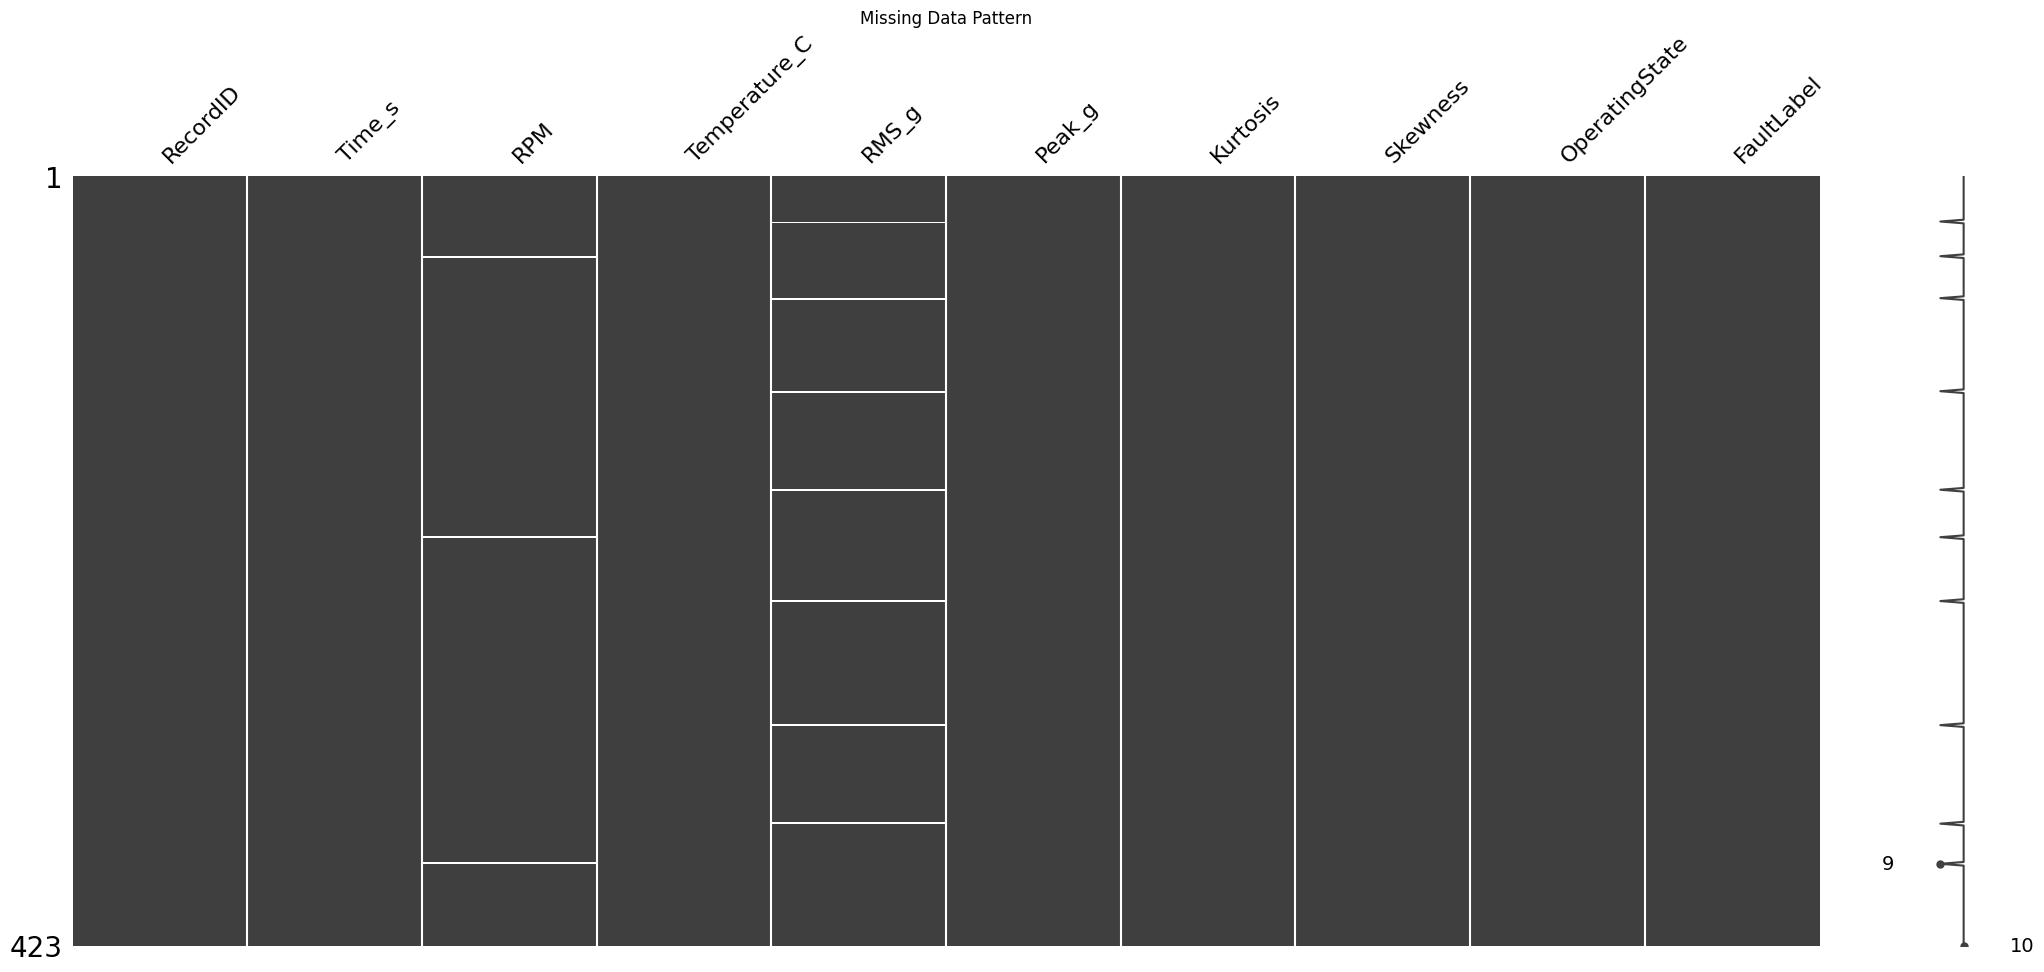

In [9]:
# Option 1: missingno matrix
msno.matrix(df)
plt.title("Missing Data Pattern")
plt.show()

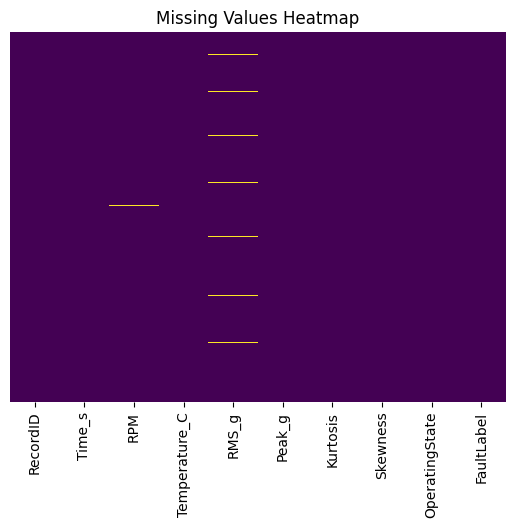

In [10]:
# Option 2: seaborn heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

#### Boxplot for Outlier Detection
Note you will need to remove the outliers and create a separate Pandas DataFrame and save the cleaned dataset as df_clean for visualisation

In [7]:
# Outlier Removal — Z-score
from scipy.stats import zscore
import numpy as np

# Example: remove extreme values in input feature 'Peak_g'
z = np.abs(zscore(df["Peak_g"], nan_policy="omit"))

# Keep observations within ±3 standard deviations
df_clean = df.loc[z < 3].copy()

print("Removed:", len(df) - len(df_clean))
print("Remaining:", len(df_clean))


Removed: 3
Remaining: 420


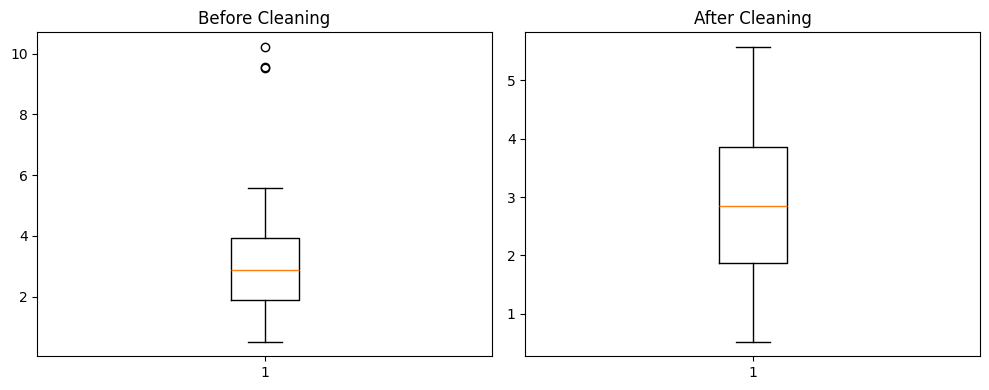

In [9]:
import matplotlib.pyplot as plt

# Single feature boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before cleaning
axes[0].boxplot(df['Peak_g'])
axes[0].set_title("Before Cleaning")

# After outlier removal
axes[1].boxplot(df_clean['Peak_g'])
axes[1].set_title("After Cleaning")

plt.tight_layout()
plt.show()

#### Feature Scaling

In [6]:
# Feature Scaling
# Reload the dataset
import pandas as pd
df = pd.read_csv('sensor_data.csv')
X = df[['Time_s',
'RPM',
'Temperature_C',
'RMS_g',
'Peak_g',
'Kurtosis',
'Skewness']]

y = df['FaultLabel']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Split first — avoid data leakage
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Standardisation: mean = 0, std = 1
print(X_train.head())
print(X_test.head())
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(X_train_s[:5])
print(X_test_s[:5])

# Alternative: scale each feature to [0, 1]
mm = MinMaxScaler()
print(X_train.head())
print(X_test.head())
X_train_mm = mm.fit_transform(X_train)
X_test_mm  = mm.transform(X_test)
print(X_train_mm[:5])
print(X_test_mm[:5])

     Time_s     RPM  Temperature_C  RMS_g  Peak_g  Kurtosis  Skewness
131     655  1579.8           51.0  0.431   1.940      5.88     -0.49
31      155  1798.5           45.7  0.218   0.763      0.64     -0.14
84      420  1794.9           47.3  0.249   0.873      3.11     -0.42
290    1450  1831.6           54.9  0.611   2.748      6.68      1.03
374    1870  1801.2           51.5  0.678   3.053      8.20     -0.01
     Time_s     RPM  Temperature_C  RMS_g  Peak_g  Kurtosis  Skewness
145     725  1837.6           57.5  0.950   4.277      7.64      0.20
280    1400  1775.6           58.6  0.952   4.282      8.26      0.51
175     875  1795.5           56.9  1.082   4.870      6.45     -0.17
410    2050  1790.4           51.2  0.569   2.559      9.40     -0.14
419    2095  1799.0           49.9  0.646   2.908      6.67     -0.28
[[-0.68310805 -0.64180061 -0.26677508 -0.75356345 -0.64458721 -0.09074057
  -1.45285399]
 [-1.53147121  0.3133732  -1.37817249 -1.52294206 -1.4503359  -3.133384

#### Preprocessing Pipelines & Dataset Splitting
Please note the following code will report **ValueError**. This is because the provided dataset contains data entry with missing values. You should use the knowledge you have learned from the lecture to handle missing data (in addition to other dataset preprocessing), before you can successfully run the whole Pipeline.

Hint: check the following links on how to handle missing values and duplicates

https://scikit-learn.org/stable/modules/impute.html

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html 


In [1]:
# Preprocessing Pipelines & Dataset Splitting
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# — 1. Split FIRST, before any preprocessing —
df = pd.read_csv('sensor_data.csv')
X = df[['Time_s',
'RPM',
'Temperature_C',
'RMS_g',
'Peak_g',
'Kurtosis',
'Skewness']]

y = df['FaultLabel']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# — 2. Build Pipeline - scaler + model together —
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

# — 3. Fit on TRAIN only —
pipeline.fit(X_train, y_train)

# — 4. Evaluate on TEST - scaler applied correctly —
score = pipeline.score(X_test, y_test)
print(f"Test Accuracy: {score:.2f}")

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values